# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [77]:
# Load the libraries as required.
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
import dask.dataframe as dd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [78]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()
fires_dt.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


,coord_x,coord_y,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


# Get X and Y

Create the features data frame and target data.

In [79]:
#Data Schema: split into Features (X) and Target(Y)
X = fires_dt.drop(columns=['area'])
Y = fires_dt['area']



In [80]:
# Create an 80:20 training and test sets,  Sets the random state to 42.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [81]:
#create preproc1 preprocessing pipeline with standard scaler and one-hot encoder
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist'), ['month', 'day'])
    ],
    remainder='passthrough'
)

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [82]:
#create preproc2 preprocessing pipeline with a quantile transformation applied to numeric features and one-hot encoder
preproc2 = ColumnTransformer(
    transformers=[
        ('num', QuantileTransformer(n_quantiles=100), ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist') , ['month', 'day'])
    ],
    remainder='passthrough'
)

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [83]:
# Pipeline A = preproc1 + baseline
#model_pipeline_a for linear regression with preproc1
model_pipeline_a = Pipeline(steps=[
    ('preprocessing', preproc1),
    ('regressor', LinearRegression())
])


In [84]:
# Pipeline B = preproc2 + baseline
#model_pipeline_b for linear regression weith preproc2
model_pipeline_b = Pipeline(steps=[
    ('preprocessing', preproc2),    
    ('regressor', LinearRegression())
])


In [85]:
# Pipeline C = preproc1 + advanced model
model_pipeline_c = Pipeline(steps=[
    ('preprocessing', preproc1),
    ('regressor', Lasso())
])

In [86]:
# Pipeline D = preproc2 + advanced model
model_pipeline_d = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', Lasso())
])

    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [87]:
#To perform the Grid Search we need to define a parameter grid:
from sklearn.model_selection import GridSearchCV
# Define the paramerer grid for linear regression models
param_grid_lr = {
    'regressor__fit_intercept': [True, False],
    'regressor__copy_X': [True, False],
    'regressor__n_jobs': [-2, -1, 0, 1, 2],
}
# Define the parameter grid for Lasso models
param_grid_lasso = {
    'regressor__alpha': [0.001, 0.1, 1.0, 10,0]
}
# Create a dictionary to hold the parameter grids for each model
param_grids = {
    'model_pipeline_a': param_grid_lr,
    'model_pipeline_b': param_grid_lr,
    'model_pipeline_c': param_grid_lasso,
    'model_pipeline_d': param_grid_lasso
}
# Create a dictionary to hold the pipelines
pipelines = {
    'model_pipeline_a': model_pipeline_a,
    'model_pipeline_b': model_pipeline_b,
    'model_pipeline_c': model_pipeline_c,
    'model_pipeline_d': model_pipeline_d
}
# Create a dictionary to hold the scoring metrics
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error
scoring = {
    'rmse': make_scorer(lambda y, yhat: mean_squared_error(y, yhat), greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False)
}




In [88]:
from sklearn.model_selection import GridSearchCV

searches = {}
cv_tables = []

for name, pipe in pipelines.items():
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring=scoring,
        refit='rmse',                 # refit on the metric you care about
        cv=5,
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    grid.fit(X_train, Y_train)
    searches[name] = grid
    
    cv_df = pd.DataFrame(grid.cv_results_)
    cv_df['pipeline'] = name
    # keep just what you want to inspect
    cv_tables.append(cv_df[['pipeline', 'params', 'mean_test_rmse', 'mean_test_mae']])

cv_results = pd.concat(cv_tables, ignore_index=True)
# remember: scores are NEGATIVE because greater_is_better=False
cv_results['rmse'] = -cv_results['mean_test_rmse']
cv_results['mae']  = -cv_results['mean_test_mae']

cv_results.sort_values('rmse', inplace=True)  # smaller RMSE is better
cv_results.head()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits


,pipeline,params,mean_test_rmse,mean_test_mae,rmse,mae
42,model_pipeline_c,{'regressor__alpha': 1.0},-2091.451899,-16.241332,2091.451899,16.241332
47,model_pipeline_d,{'regressor__alpha': 1.0},-2091.956816,-15.710557,2091.956816,15.710557
43,model_pipeline_c,{'regressor__alpha': 10},-2097.837331,-15.734796,2097.837331,15.734796
48,model_pipeline_d,{'regressor__alpha': 10},-2097.837331,-15.734796,2097.837331,15.734796
46,model_pipeline_d,{'regressor__alpha': 0.1},-2157.969322,-17.338696,2157.969322,17.338696


# Evaluate

+ Which model has the best performance?

In [89]:
# report the best model and its parameters from the search
best_model_name = cv_results.iloc[0]['pipeline']
best_model = searches[best_model_name].best_estimator_
best_params = searches[best_model_name].best_params_
print(f"Best model: {best_model_name}")
print(f"Best parameters: {best_params}")
# Evaluate the best model on the test set
best_model.fit(X_train, Y_train) 
Y_pred = best_model.predict(X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
print(f"RMSE on test set: {rmse}")
print(f"MAE on test set: {mae}")

Best model: model_pipeline_c
Best parameters: {'regressor__alpha': 1.0}
RMSE on test set: 11787.918295032578
MAE on test set: 24.527581332249376


# Export

+ Save the best performing model to a pickle file.

In [90]:
# Save the best model
import joblib
model_filename = 'best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model saved to {model_filename}")

Best model saved to best_model.pkl


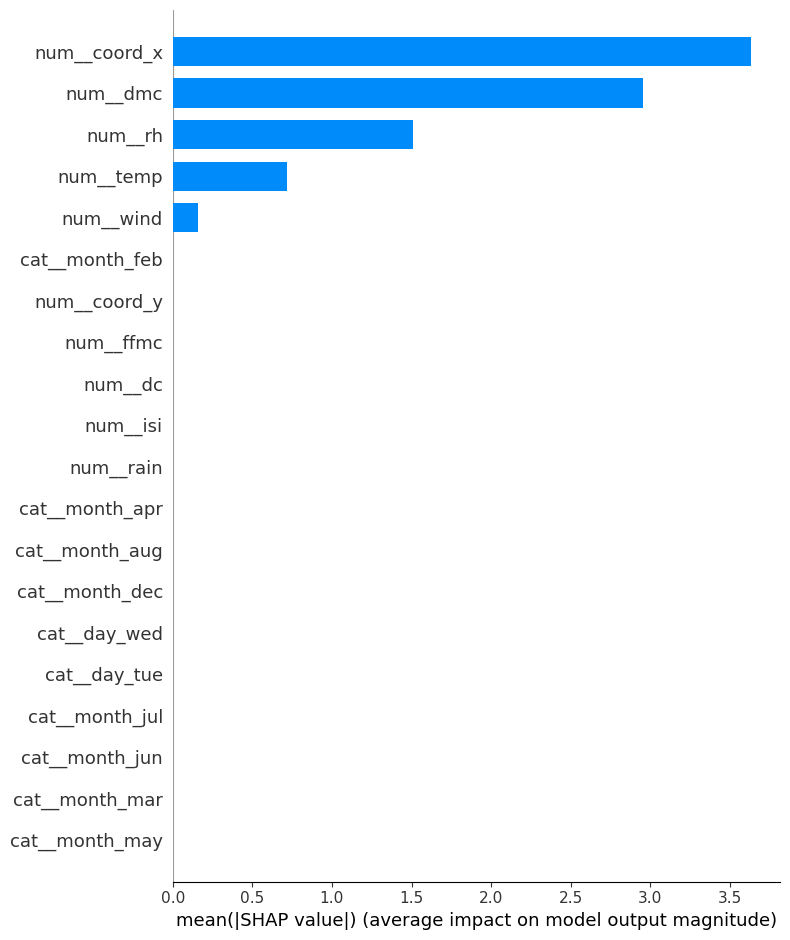

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

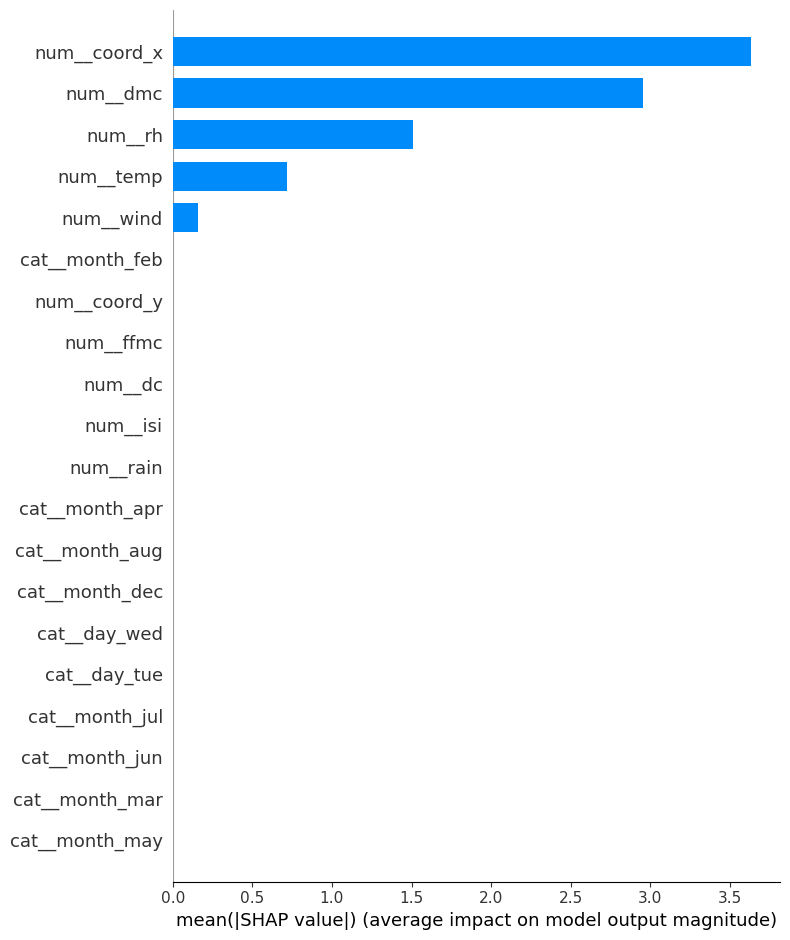

In [125]:
import shap

# Get fitted preprocessor from the pipeline
preproc = best_model.named_steps['preprocessing']
regressor = best_model.named_steps['regressor']

# Transform data
X_train_t = preproc.transform(X_train)
X_test_t = preproc.transform(X_test)

# Get feature names
try:
    feature_names = preproc.get_feature_names_out()
except:
    feature_names = [f'feature_{i}' for i in range(X_train_t.shape[1])]

# Create SHAP explainer for linear model
explainer = shap.explainers.Linear(
    model=regressor,
    masker=X_train_t,
    feature_names=feature_names
)

# Get SHAP values for the test data
shap_values = explainer(X_test_t)

# Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.
shap.initjs()
shap.force_plot(shap_values[0])
shap.summary_plot(shap_values, feature_names=feature_names, plot_type='bar')




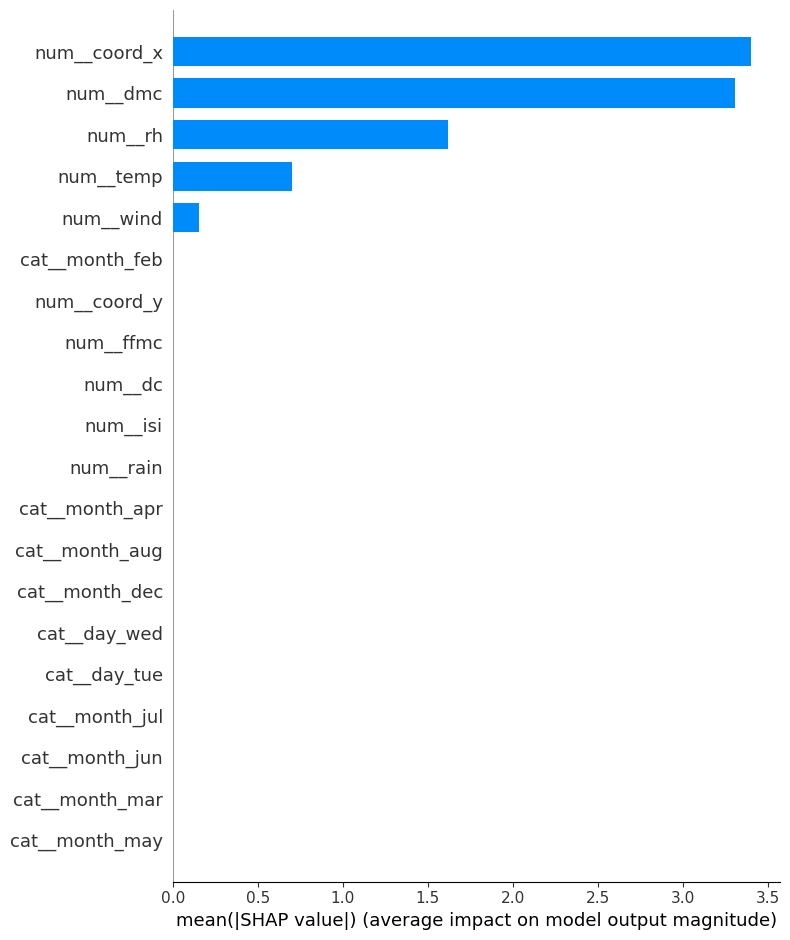

In [123]:
#In general, across the complete training set, which features are the most and least important.
data_transform = preproc.transform(X_train)
explainer = shap.explainers.Linear(
    regressor, 
    data_transform,
    feature_names=preproc.get_feature_names_out()
)
shap_values = explainer(data_transform)
shap.summary_plot(shap_values, feature_names=preproc.get_feature_names_out(), plot_type='bar')


If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

Based on SHAPS scores the following are less important to the model and would be candidates for removal: 
1. months of the year 
2. days of the week 
3. rain
4. ISI index
5. DC index
6. FFMC index
7. y coordinates

I would probably take an interative/stepwise approach starting with removing month of the year given that this is a candidate for high colinearity to the measures of weather. Days of the week may be somewhat arbitrary as well.

If the various weather indices are still relatively non informative after removing potential colinearity from month, these would be candidates for removal as well.

It's surprising that Y-coord was unrelated given the x coord was a strong predictor. It's possible that in this case the East-West location is more impactful than the North-South but this requires further exploration.


Removal could reduce model complexity (i.e. more parsimonious) and risk of overfitting. Interpretability may also improve through simplification and reducing those issues around collinearity. Finally, fewer data features would speed up training/prediction time (especially with large models).

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.